In [ ]:
import kagglehub

# Download latest version
base_path = kagglehub.dataset_download("sovitrath/water-bodies-segmentation-dataset-with-split")

print("Path to dataset files:", base_path)

Path to dataset files: /kaggle/input/water-bodies-segmentation-dataset-with-split


In [ ]:
import os
from sklearn.model_selection import train_test_split
import glob
image_dir = os.path.join(base_path, 'Water_Bodies_Dataset_Split', 'train_images')
mask_dir = os.path.join(base_path, 'Water_Bodies_Dataset_Split', 'train_masks')

all_images_train = sorted(glob.glob(os.path.join(image_dir, '*.jpg')))
all_masks_train = sorted(glob.glob(os.path.join(mask_dir, '*.jpg')))


subset_size = 1000
images_subset = all_images_train[:subset_size]
masks_subset = all_masks_train[:subset_size]

In [ ]:
image_dir1 = os.path.join(base_path, 'Water_Bodies_Dataset_Split', 'valid_images')
mask_dir1 = os.path.join(base_path, 'Water_Bodies_Dataset_Split', 'valid_masks')


all_images_valid = sorted(glob.glob(os.path.join(image_dir1, '*.jpg')))
all_masks_valid = sorted(glob.glob(os.path.join(mask_dir1, '*.jpg')))

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 99s 966ms/step - accuracy: 0.6526 - loss: 0.6343 - val_accuracy: 0.7552 - val_loss: 0.5008
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 68s 303ms/step - accuracy: 0.7528 - loss: 0.5094 - val_accuracy: 0.7512 - val_loss: 0.5081
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 300ms/step - accuracy: 0.7525 - loss: 0.5214 - val_accuracy: 0.7625 - val_loss: 0.4713
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 305ms/step - accuracy: 0.7657 - loss: 0.4915 - val_accuracy: 0.7631 - val_loss: 0.4653
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 296ms/step - accuracy: 0.7918 - loss: 0.4523 - val_accuracy: 0.7856 - val_loss: 0.4606
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 303ms/step - accuracy: 0.7898 - loss: 0.4597 - val_accuracy: 0.7179 - val_loss: 0.5133
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 298ms/step - accuracy: 0.7573 - loss: 0.5040 - val_accuracy: 0.8026 - val_loss: 0.4362
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 305ms/step - accuracy: 0.8023 - loss: 0.4505 - val_accu

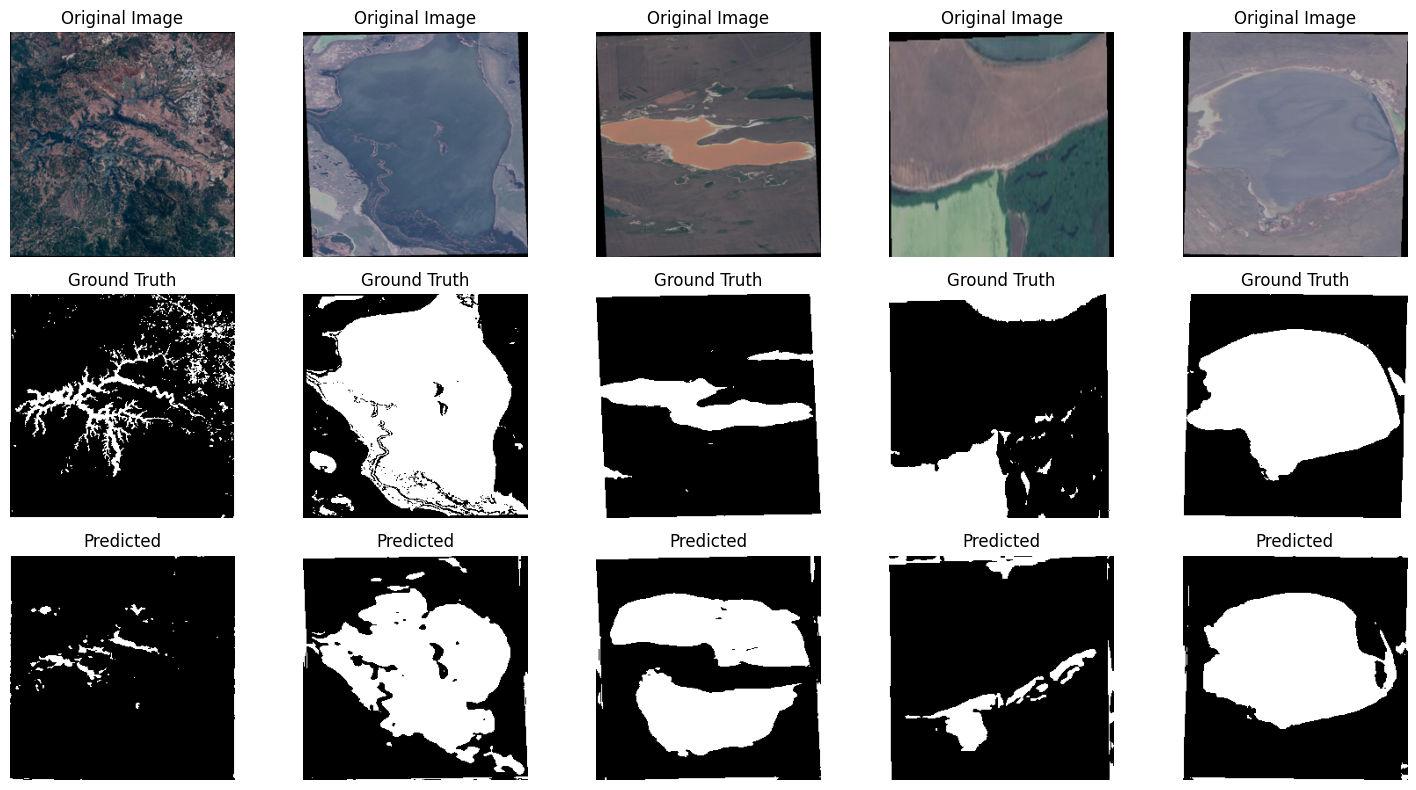

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step


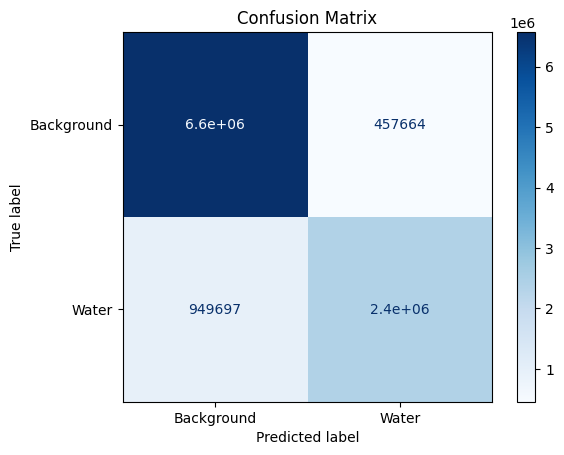

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, ReLU, Softmax, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Accuracy
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming your image and mask directories are already defined from the previous code
# image_dir, mask_dir for training
# image_dir1, mask_dir1 for validation

# Load and preprocess data (assuming images are RGB and masks are grayscale with values 0 or 255)
def load_data(image_paths, mask_paths, target_size=(256, 256)):
    images = []
    masks = []
    for img_path, mask_path in zip(image_paths, mask_paths):
        img = Image.open(img_path).convert('RGB')
        img = img.resize(target_size)
        img = np.array(img) / 255.0  # Normalize to [0, 1]
        images.append(img)

        mask = Image.open(mask_path).convert('L') # Convert to grayscale
        mask = mask.resize(target_size)
        mask = np.array(mask)
        # Convert mask to one-hot encoding (assuming 2 classes: 0 and 255)
        mask = np.where(mask > 128, 1, 0) # Binarize to 0 and 1
        mask = tf.keras.utils.to_categorical(mask, num_classes=2)
        masks.append(mask)
    return np.array(images), np.array(masks)

# Load a subset of training and validation data
train_images, train_masks = load_data(images_subset, masks_subset)
valid_images, valid_masks = load_data(all_images_valid, all_masks_valid)


# Define the MSR-Net model
def msr_net(input_shape=(256, 256, 3), num_classes=2):
    inputs = Input(input_shape)

    # Encoder
    conv1 = Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    conv1 = Conv2D(32, (3, 3), padding='same', activation='relu')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), padding='same', activation='relu')(pool1)
    conv2 = Conv2D(64, (3, 3), padding='same', activation='relu')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), padding='same', activation='relu')(pool2)
    conv3 = Conv2D(128, (3, 3), padding='same', activation='relu')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(256, (3, 3), padding='same', activation='relu')(pool3)
    conv4 = Conv2D(256, (3, 3), padding='same', activation='relu')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    conv5 = Conv2D(512, (3, 3), padding='same', activation='relu')(pool4)
    conv5 = Conv2D(512, (3, 3), padding='same', activation='relu')(conv5)
    # Optional: Add dropout for regularization
    conv5 = Dropout(0.5)(conv5)


    # Decoder
    up6 = UpSampling2D(size=(2, 2))(conv5)
    up6 = concatenate([up6, conv4], axis=3)
    conv6 = Conv2D(256, (3, 3), padding='same', activation='relu')(up6)
    conv6 = Conv2D(256, (3, 3), padding='same', activation='relu')(conv6)

    up7 = UpSampling2D(size=(2, 2))(conv6)
    up7 = concatenate([up7, conv3], axis=3)
    conv7 = Conv2D(128, (3, 3), padding='same', activation='relu')(up7)
    conv7 = Conv2D(128, (3, 3), padding='same', activation='relu')(conv7)

    up8 = UpSampling2D(size=(2, 2))(conv7)
    up8 = concatenate([up8, conv2], axis=3)
    conv8 = Conv2D(64, (3, 3), padding='same', activation='relu')(up8)
    conv8 = Conv2D(64, (3, 3), padding='same', activation='relu')(conv8)

    up9 = UpSampling2D(size=(2, 2))(conv8)
    up9 = concatenate([up9, conv1], axis=3)
    conv9 = Conv2D(32, (3, 3), padding='same', activation='relu')(up9)
    conv9 = Conv2D(32, (3, 3), padding='same', activation='relu')(conv9)

    # Output layer with Softmax activation
    outputs = Conv2D(num_classes, (1, 1), activation='softmax')(conv9)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Create and compile the model
model = msr_net()
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_images, train_masks, epochs=30, batch_size=16, validation_data=(valid_images, valid_masks))

# Evaluate the model
loss, accuracy = model.evaluate(train_images, train_masks, verbose=0)
val_loss, val_accuracy = model.evaluate(valid_images, valid_masks, verbose=0)

print(f"Training Accuracy: {accuracy:.4f}")
print(f"Training Loss: {loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

# Generate and display 5 example predictions
num_examples = 5
predictions = model.predict(valid_images[:num_examples])

plt.figure(figsize=(15, 8))
for i in range(num_examples):
    # Original Image
    plt.subplot(3, num_examples, i + 1)
    plt.imshow(valid_images[i])
    plt.title("Original Image")
    plt.axis('off')

    # Ground Truth Mask
    plt.subplot(3, num_examples, i + num_examples + 1)
    plt.imshow(np.argmax(valid_masks[i], axis=-1), cmap='gray') # Convert one-hot to grayscale
    plt.title("Ground Truth")
    plt.axis('off')

    # Predicted Mask
    plt.subplot(3, num_examples, i + 2 * num_examples + 1)
    plt.imshow(np.argmax(predictions[i], axis=-1), cmap='gray') # Convert one-hot to grayscale
    plt.title("Predicted")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Generate and display confusion matrix
# Get predictions for the entire validation set
all_predictions = model.predict(valid_images)
# Convert predictions and ground truth to class indices
predicted_classes = np.argmax(all_predictions, axis=-1).flatten()
true_classes = np.argmax(valid_masks, axis=-1).flatten()

cm = confusion_matrix(true_classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Background', 'Water'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

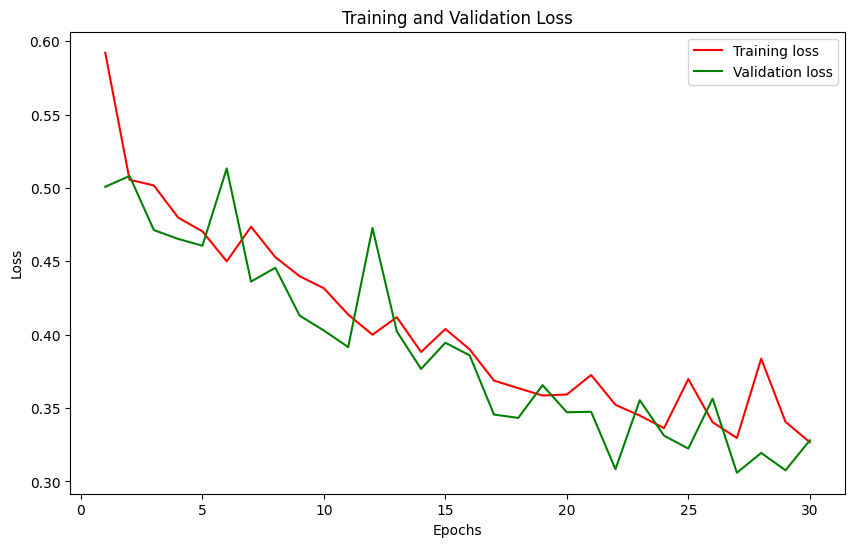

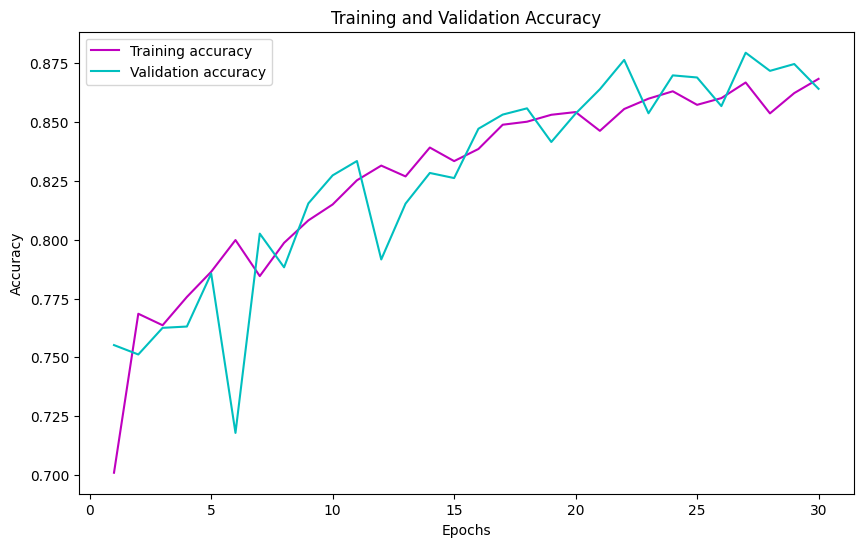

In [ ]:
# Access the history object from model training
history_dict = history.history

# Get loss and validation loss values
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

# Get accuracy and validation accuracy values
accuracy_values = history_dict['accuracy']
val_accuracy_values = history_dict['val_accuracy']

# Get the number of epochs
epochs = range(1, len(loss_values) + 1)

# Plotting loss and validation loss with different colors
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_values, 'r', label='Training loss')  # 'r' for red line
plt.plot(epochs, val_loss_values, 'g', label='Validation loss') # 'g' for green line
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plotting accuracy and validation accuracy with different colors
plt.figure(figsize=(10, 6))
plt.plot(epochs, accuracy_values, 'm', label='Training accuracy') # 'm' for magenta line
plt.plot(epochs, val_accuracy_values, 'c', label='Validation accuracy') # 'c' for cyan line
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()